# Direct Acoustic vs. Multi-Hop Optical Link Benchmark

This notebook automates parameter sweeps comparing a single-hop acoustic underwater baseline against multi-hop optical links (ordinary optical and optical with beam pattern/LUT) across:
- **Total Distance** (20 m to 100 m)
- **Relay Count** (0 to 4 relay couples)
- **Offered Traffic** (CBR period from 0.005 s to 1.0 s, Poisson traffic)
- **Packet Size** (64 to 500 bytes)

In [9]:
import math
import re
import shlex
import statistics
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Output parser regexes
SENT_RE = re.compile(r"sent packets:\s*([0-9]+(?:\.[0-9]+)?)")
RECEIVED_RE = re.compile(r"received packets:\s*([0-9]+(?:\.[0-9]+)?)")
FTT_RE = re.compile(r"forward trip time mean:\s*([-+0-9.eE]+)")
FTT_STD_RE = re.compile(r"forward trip time std:\s*([-+0-9.eE]+)")
MAC_RE = re.compile(
    r"^\s*modem\s+(\d+):\s+([0-9.eE+-]+)\s+([0-9.eE+-]+)",
    re.MULTILINE,
)
print("Imports and regex parsers ready.")

Imports and regex parsers ready.


### 1. Environment and Path Configuration
Set up paths for DESERT environment source script, TCL models, and logging directories.

In [10]:
NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = NOTEBOOK_DIR.parents[5] if len(NOTEBOOK_DIR.parents) >= 5 else NOTEBOOK_DIR


ENV_PATH = REPO_ROOT / "DESERT_buildCopy_LOCAL" / "environment"
OPTICAL_SIM = NOTEBOOK_DIR / "multi_hop_optical_tdma.tcl"
BEAM_SIM = NOTEBOOK_DIR / "multi_hop_optical_tdma_beampattern.tcl"
ACOUSTIC_SIM = NOTEBOOK_DIR / "single_link_comp.tcl"

OUTPUT_DIR = NOTEBOOK_DIR / "optical_acoustic_comparison_results"
LOGS_DIR = OUTPUT_DIR / "logs"
LOGS_DIR.mkdir(parents=True, exist_ok=True)

REPETITIONS = 3
print(f"Results output path: {OUTPUT_DIR}")

Results output path: /home/pietro/signet/repos/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results


### 2. Simulation Execution Function
Encapsulates shell invocation under `zsh -lc`, collects stdout/stderr, and extracts metrics.

In [11]:
def optical_hop_length(total_distance: float, n_relays: int, relay_gap: float) -> float:
    length = (total_distance - n_relays * relay_gap) / (n_relays + 1)
    if length <= 0:
        raise ValueError("Total distance is too short for the requested relay gaps.")
    return length


def run_case(environment: Path, simulation: Path, workdir: Path, log_path: Path,
             *, technology: str, n_relays: int, total_distance: float,
             cbr_period: float, packet_size: int, depth: float,
             stop_time: float, rngstream: int, relay_gap: float,
             attenuation_scale: float, poisson_traffic: int,
             optical_txpower: float, optical_threshold: float,
             optical_theta: float) -> dict:
    is_optical = technology != "acoustic"
    hop_length = optical_hop_length(total_distance, n_relays, relay_gap)
    values = [
        n_relays, cbr_period, packet_size,
        hop_length if is_optical else total_distance,
        relay_gap, depth, stop_time, rngstream, attenuation_scale, poisson_traffic
    ]
    if is_optical:
        values.extend(["", optical_txpower, optical_threshold, optical_theta])
    command = "source {env} && ns {simulation} {args}".format(
        env=shlex.quote(str(environment.resolve())),
        simulation=shlex.quote(str(simulation.resolve())),
        args=" ".join(shlex.quote(str(v)) for v in values),
    )
    completed = subprocess.run(
        ["zsh", "-lc", command], cwd=workdir, text=True, capture_output=True, check=False
    )
    output = completed.stdout + completed.stderr
    log_path.write_text(output, encoding="utf-8")
    
    if completed.returncode != 0:
        raise RuntimeError(f"Simulation failed; check {log_path}")

    sent_match = SENT_RE.search(output)
    received_match = RECEIVED_RE.search(output)
    if sent_match is None or received_match is None:
        raise RuntimeError(f"Could not parse packet counters; check {log_path}")
    sent = float(sent_match.group(1))
    received = float(received_match.group(1))
    ftt_match = FTT_RE.search(output)
    ftt_std_match = FTT_STD_RE.search(output)

    hop_pdrs = []
    if is_optical:
        mac = {int(node): (float(s), float(r)) for node, s, r in MAC_RE.findall(output)}
        for hop in range(n_relays + 1):
            transmitted = mac.get(hop, (0.0, 0.0))[0]
            received_hop = mac.get(hop + 1, (0.0, 0.0))[1]
            hop_pdrs.append(received_hop / transmitted if transmitted else math.nan)
    finite_hops = [v for v in hop_pdrs if math.isfinite(v)]
    return {
        "technology": technology,
        "n_relays": n_relays,
        "hop_count": n_relays + 1 if is_optical else 1,
        "total_distance": total_distance,
        "hop_length": hop_length if is_optical else total_distance,
        "sent_packets": sent,
        "received_packets": received,
        "pdr": received / sent if sent else math.nan,
        "goodput_bps": received * packet_size * 8.0 / stop_time,
        "delay_mean_s": float(ftt_match.group(1)) if ftt_match else math.nan,
        "delay_std_s": float(ftt_std_match.group(1)) if ftt_std_match else math.nan,
        "mean_hop_pdr": statistics.mean(finite_hops) if finite_hops else math.nan,
        "weakest_hop_pdr": min(finite_hops) if finite_hops else math.nan,
    }

### 3. Generate Full Sweep Cases
Includes all 4 parameter sweeps active simultaneously (distance, relays, offered traffic, packet size).

In [12]:
import yaml

with open("./multi_hop_optical_tdma_opt.yaml") as params:
    params_yaml = yaml.load(params, Loader=yaml.SafeLoader)

common = {
    "cbr_period": params_yaml['opt']['cbr_period'],
    "packet_size": params_yaml['opt']['pktsize'],
    "depth": params_yaml['opt']['depth'],
    "stop_time": params_yaml['opt']['stoptime'],
    "relay_gap": params_yaml['opt']['relay_gap'],
    "attenuation_scale": params_yaml['opt']['attenuation_scale'],
    "poisson_traffic": params_yaml['opt']['poisson_traffic'],
    "optical_txpower": params_yaml['opt']['txpower'],
    "optical_threshold": params_yaml['opt']['acq_threshold_db'],
    "optical_theta": params_yaml['opt']['theta'],
}

cases = []


def add(sweep: str, value: float, n_relays: int, technologies: tuple, **overrides) -> None:
    base = dict(common)
    base.update({"n_relays": n_relays, "total_distance": 50.0})
    base.update(overrides)
    for technology in technologies:
        for repetition in range(1, REPETITIONS + 1):
            case = dict(base)
            case.update({
                "sweep": sweep,
                "sweep_value": value,
                "technology": technology,
                "rngstream": repetition,
            })
            if sweep == "relay_count": print(case)
            cases.append(case)


# 1. Total distance sweep
for distance in (20.0, 40.0, 60.0, 80.0, 100.0):
    add(
        "total_distance",
        distance,
        2,
        ("acoustic", "optical", "beam_optical"),
        total_distance=distance,
    )

# 2. Relay count sweep
for n_relays in (1, 2, 3, 4):
    add(
        "relay_count",
        float(n_relays),
        n_relays,
        ("acoustic", "optical", "beam_optical"),
    )

# 3. Traffic interval sweep (Poisson)
for period in (0.005, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0):
    add(
        "offered_traffic",
        period,
        2,
        ("acoustic", "optical", "beam_optical"),
        cbr_period=period,
        poisson_traffic=1,
    )

# 4. Packet size sweep
for packet_size in (64, 125, 250, 500):
    add(
        "packet_size",
        float(packet_size),
        2,
        ("acoustic", "optical", "beam_optical"),
        packet_size=packet_size,
    )

print(f"Total experiment runs scheduled: {len(cases)}")


{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 1, 'total_distance': 50.0, 'sweep': 'relay_count', 'sweep_value': 1.0, 'technology': 'acoustic', 'rngstream': 1}
{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 1, 'total_distance': 50.0, 'sweep': 'relay_count', 'sweep_value': 1.0, 'technology': 'acoustic', 'rngstream': 2}
{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 1, 'total_distance': 50.0, 'sweep': 'relay_count', 'sweep_value': 1.0, 'techno

In [13]:

for case in cases:
    print(case)


{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 2, 'total_distance': 20.0, 'sweep': 'total_distance', 'sweep_value': 20.0, 'technology': 'acoustic', 'rngstream': 1}
{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 2, 'total_distance': 20.0, 'sweep': 'total_distance', 'sweep_value': 20.0, 'technology': 'acoustic', 'rngstream': 2}
{'cbr_period': 0.1, 'packet_size': 1400, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 2, 'total_distance': 20.0, 'sweep': 'total_distance', 'sweep_value': 2

### 4. Execute Simulation Suite
Executes all cases, parses log files, and persists raw observations to `results.csv`.

In [14]:
sim_map = {
    "acoustic": ACOUSTIC_SIM,
    "optical": OPTICAL_SIM,
    "beam_optical": BEAM_SIM,
}

rows = []
for idx, case in enumerate(cases, 1):
    tech = str(case["technology"])
    sim_file = sim_map[tech]
    log_path = LOGS_DIR / f"{idx:03d}_{tech}_{case['sweep']}_{case['sweep_value']}.log"
    print(f"[{idx:03d}/{len(cases):03d}] {tech:12s} | {case['sweep']}={case['sweep_value']} | Rep: {case['rngstream']}")
    result = run_case(
        ENV_PATH,
        sim_file,
        sim_file.parent,
        log_path,
        **{
            k: case[k]
            for k in (
                "technology",
                "n_relays",
                "total_distance",
                "cbr_period",
                "packet_size",
                "depth",
                "stop_time",
                "rngstream",
                "relay_gap",
                "attenuation_scale",
                "poisson_traffic",
                "optical_txpower",
                "optical_threshold",
                "optical_theta",
            )
        },
    )
    result.update({
        "sweep": case["sweep"],
        "sweep_value": case["sweep_value"],
        "rngstream": case["rngstream"],
    })
    rows.append(result)

df_results = pd.DataFrame(rows)
df_results.to_csv(OUTPUT_DIR / "results.csv", index=False)
print("Runs complete. Raw data exported to results.csv")
df_results.head()

[001/189] acoustic     | total_distance=20.0 | Rep: 1
[002/189] acoustic     | total_distance=20.0 | Rep: 2
[003/189] acoustic     | total_distance=20.0 | Rep: 3
[004/189] optical      | total_distance=20.0 | Rep: 1
[005/189] optical      | total_distance=20.0 | Rep: 2
[006/189] optical      | total_distance=20.0 | Rep: 3
[007/189] beam_optical | total_distance=20.0 | Rep: 1
[008/189] beam_optical | total_distance=20.0 | Rep: 2
[009/189] beam_optical | total_distance=20.0 | Rep: 3
[010/189] acoustic     | total_distance=40.0 | Rep: 1
[011/189] acoustic     | total_distance=40.0 | Rep: 2
[012/189] acoustic     | total_distance=40.0 | Rep: 3
[013/189] optical      | total_distance=40.0 | Rep: 1
[014/189] optical      | total_distance=40.0 | Rep: 2
[015/189] optical      | total_distance=40.0 | Rep: 3
[016/189] beam_optical | total_distance=40.0 | Rep: 1
[017/189] beam_optical | total_distance=40.0 | Rep: 2
[018/189] beam_optical | total_distance=40.0 | Rep: 3
[019/189] acoustic     | tot

,technology,n_relays,hop_count,total_distance,hop_length,sent_packets,received_packets,pdr,goodput_bps,delay_mean_s,delay_std_s,mean_hop_pdr,weakest_hop_pdr,sweep,sweep_value,rngstream
0,acoustic,2,1,20.0,20.0,9853.0,1519.0,0.154166,17012.8,7.021380,0.327094,NaN,NaN,total_distance,20.0,1
1,acoustic,2,1,20.0,20.0,9912.0,1519.0,0.153249,17012.8,7.020948,0.327337,NaN,NaN,total_distance,20.0,2
2,acoustic,2,1,20.0,20.0,9810.0,1519.0,0.154842,17012.8,7.019567,0.324574,NaN,NaN,total_distance,20.0,3
3,optical,2,3,20.0,6.0,9741.0,9741.0,1.000000,109099.2,0.278965,0.136986,1.0,1.0,total_distance,20.0,1
4,optical,2,3,20.0,6.0,9946.0,9946.0,1.000000,111395.2,0.283195,0.146572,1.0,1.0,total_distance,20.0,2


### 5. Aggregate Summaries
Computes mean and standard deviation per sweep condition and exports to `summary.csv`.

In [15]:
metrics = [
    "pdr",
    "goodput_bps",
    "delay_mean_s",
    "mean_hop_pdr",
    "weakest_hop_pdr",
]
agg_spec = {m: ["mean", "std"] for m in metrics}

df_summary = (
    df_results.groupby(["technology", "sweep", "sweep_value"], as_index=False)
    .agg(agg_spec)
)
df_summary.columns = [
    f"{c[0]}_{c[1]}".strip("_") if c[1] else c[0] for c in df_summary.columns
]
# Compute count of repetitions
rep_counts = (
    df_results.groupby(["technology", "sweep", "sweep_value"])["rngstream"]
    .count()
    .reset_index(name="repetitions")
)
df_summary = pd.merge(rep_counts, df_summary, on=["technology", "sweep", "sweep_value"])
df_summary = df_summary.fillna(0.0)
df_summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
print("Summary table created.")
df_summary.head(10)

Summary table created.


,technology,sweep,sweep_value,repetitions,pdr_mean,pdr_std,goodput_bps_mean,goodput_bps_std,delay_mean_s_mean,delay_mean_s_std,mean_hop_pdr_mean,mean_hop_pdr_std,weakest_hop_pdr_mean,weakest_hop_pdr_std
0,acoustic,offered_traffic,0.005,3,0.002575,0.000004,5745.600000,0.000000,7.086491,0.000178,0.0,0.0,0.0,0.0
1,acoustic,offered_traffic,0.010,3,0.010178,0.000011,11349.333333,12.932646,7.118084,0.000286,0.0,0.0,0.0,0.0
2,acoustic,offered_traffic,0.020,3,0.030701,0.000053,17024.000000,0.000000,7.120458,0.000328,0.0,0.0,0.0,0.0
3,acoustic,offered_traffic,0.050,3,0.076755,0.000203,17012.800000,0.000000,7.094883,0.001411,0.0,0.0,0.0,0.0
4,acoustic,offered_traffic,0.100,3,0.153997,0.000755,17012.800000,0.000000,7.040626,0.001198,0.0,0.0,0.0,0.0
5,acoustic,offered_traffic,0.250,3,0.390117,0.006054,17012.800000,0.000000,6.853573,0.007376,0.0,0.0,0.0,0.0
6,acoustic,offered_traffic,0.500,3,0.785208,0.009525,16997.866667,12.932646,5.875843,0.021577,0.0,0.0,0.0,0.0
7,acoustic,offered_traffic,1.000,3,1.000000,0.000000,10882.666667,516.456439,1.317258,0.126066,0.0,0.0,0.0,0.0
8,acoustic,packet_size,64.000,3,0.203376,0.001448,1026.048000,0.000000,4.901068,0.003413,0.0,0.0,0.0,0.0
9,acoustic,packet_size,125.000,3,0.202619,0.001126,2004.000000,0.000000,4.934703,0.003992,0.0,0.0,0.0,0.0


### 6. Plotting Results
Generates 1x4 subplots for each of the 4 sweep experiments (PDR, Goodput, Mean Delay, Weakest Optical-Hop PDR) and saves figures to disk.

Saved plot: /home/pietro/signet/repos/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_total_distance.png


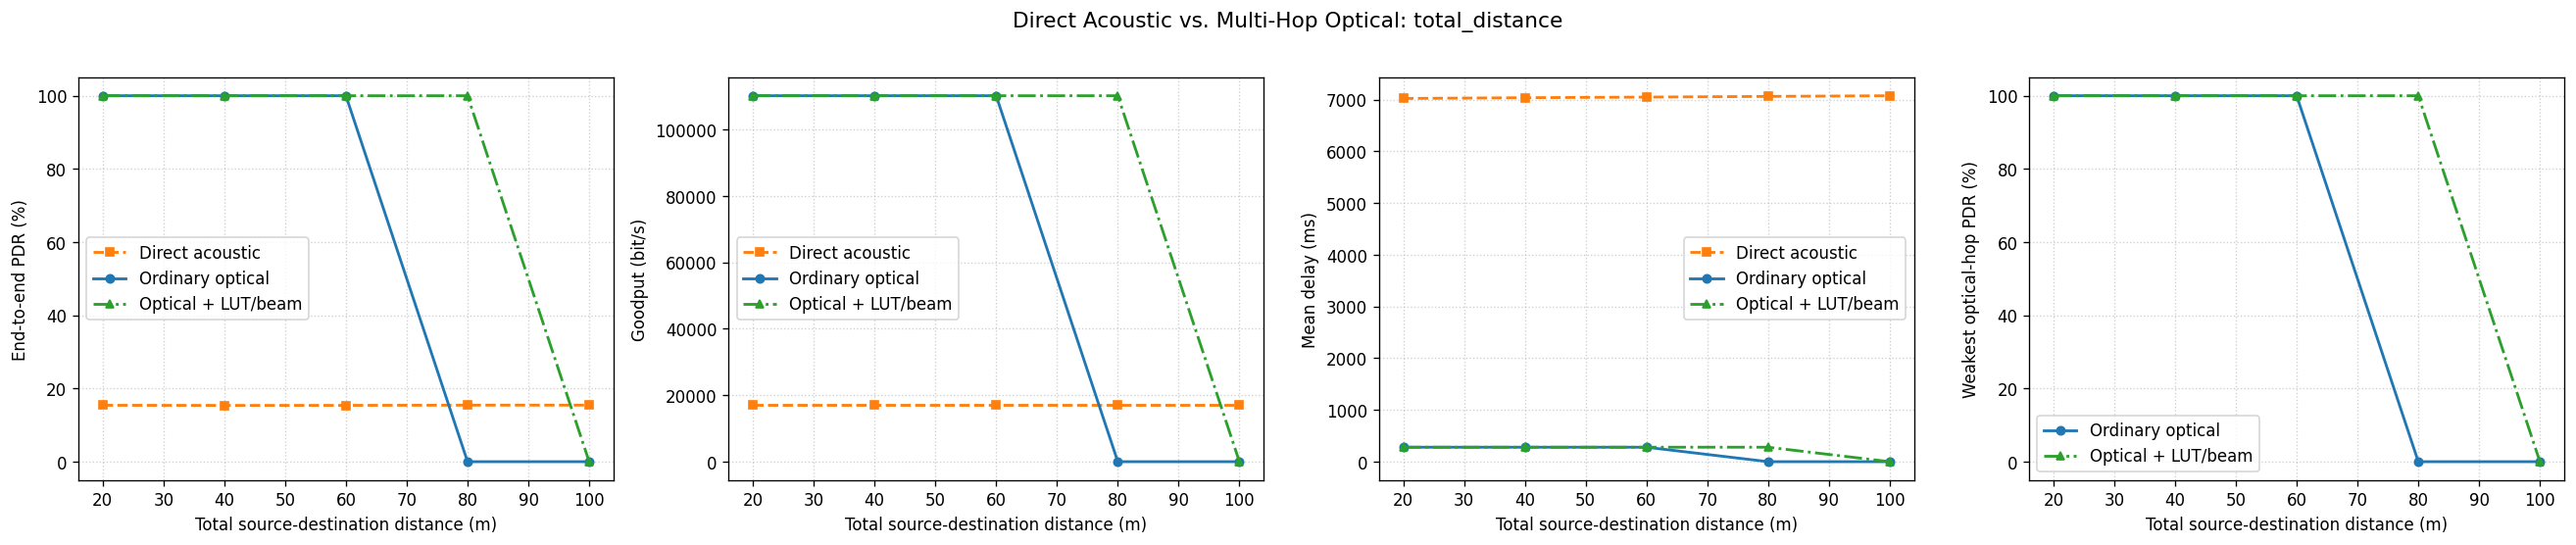

Saved plot: /home/pietro/signet/repos/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_relay_count.png


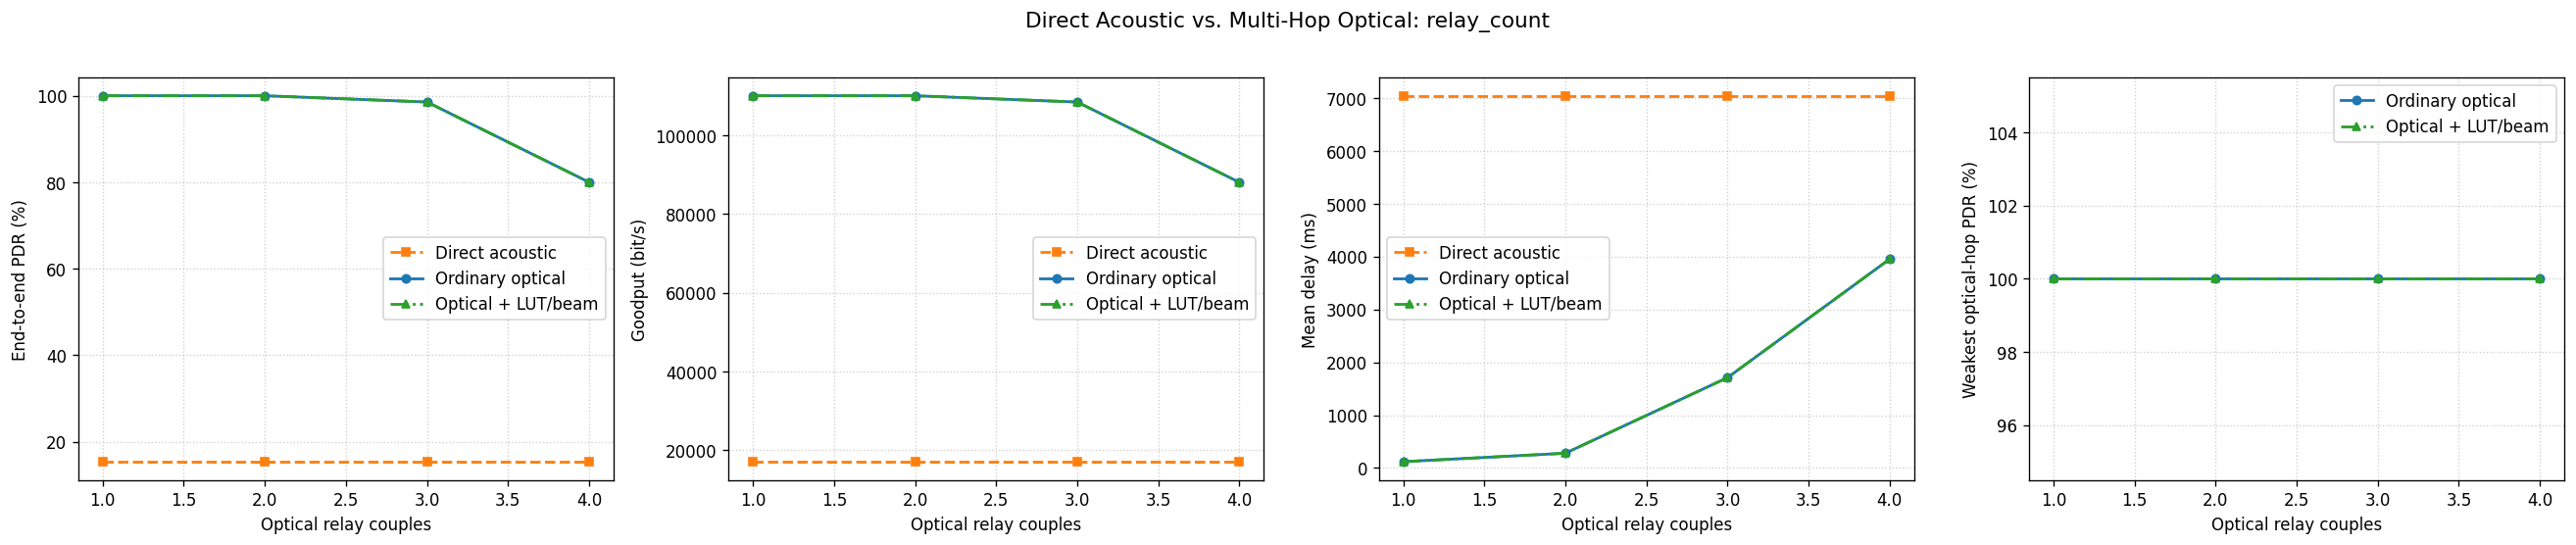

Saved plot: /home/pietro/signet/repos/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_offered_traffic.png


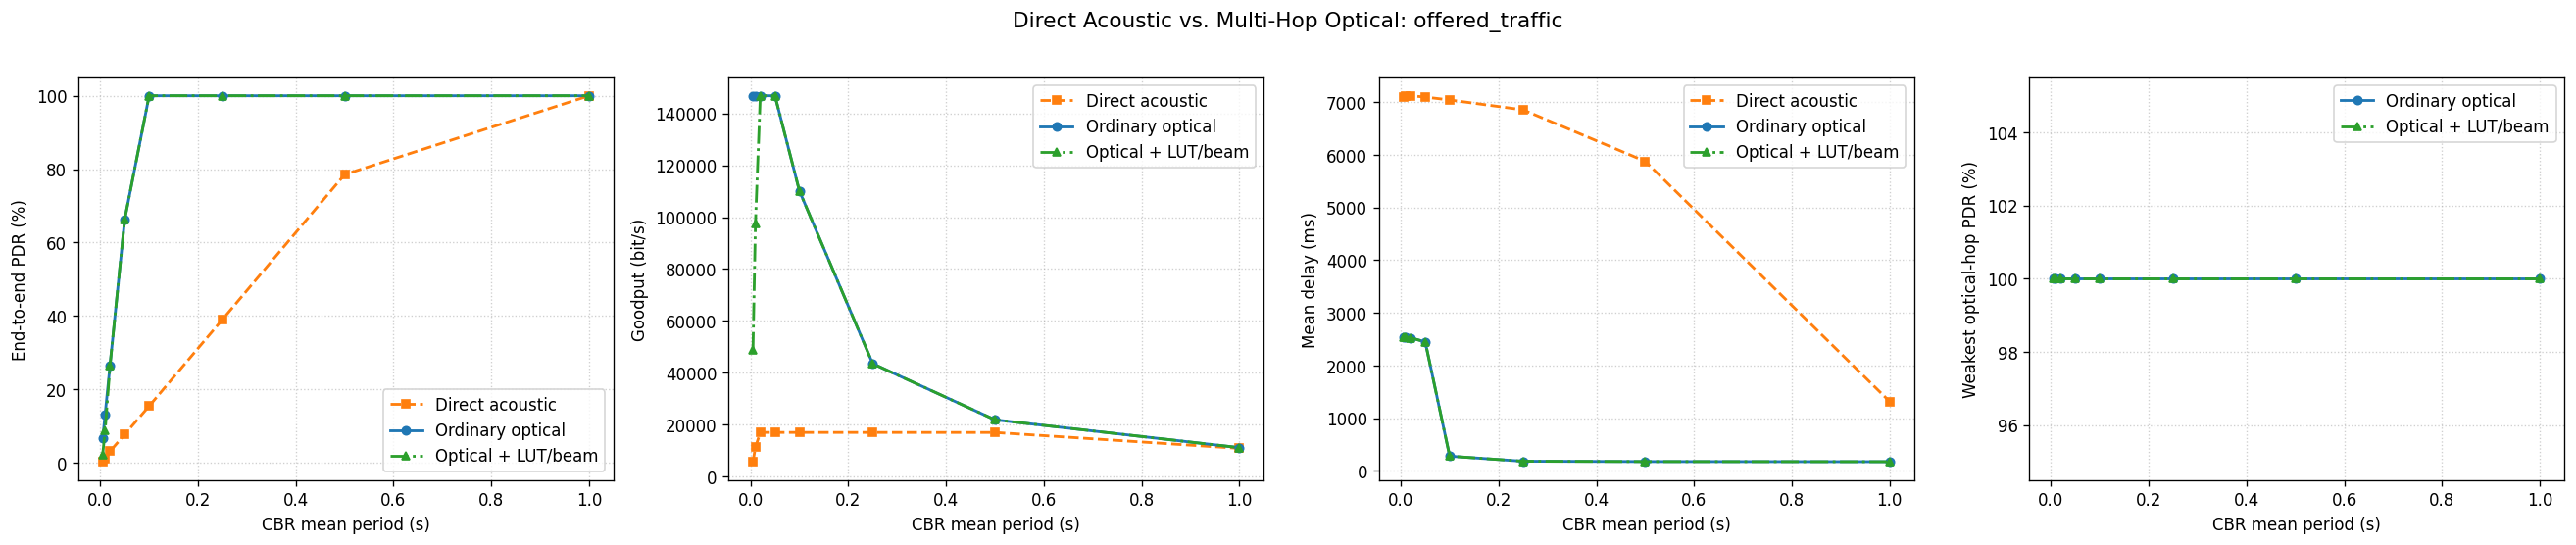

Saved plot: /home/pietro/signet/repos/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_packet_size.png


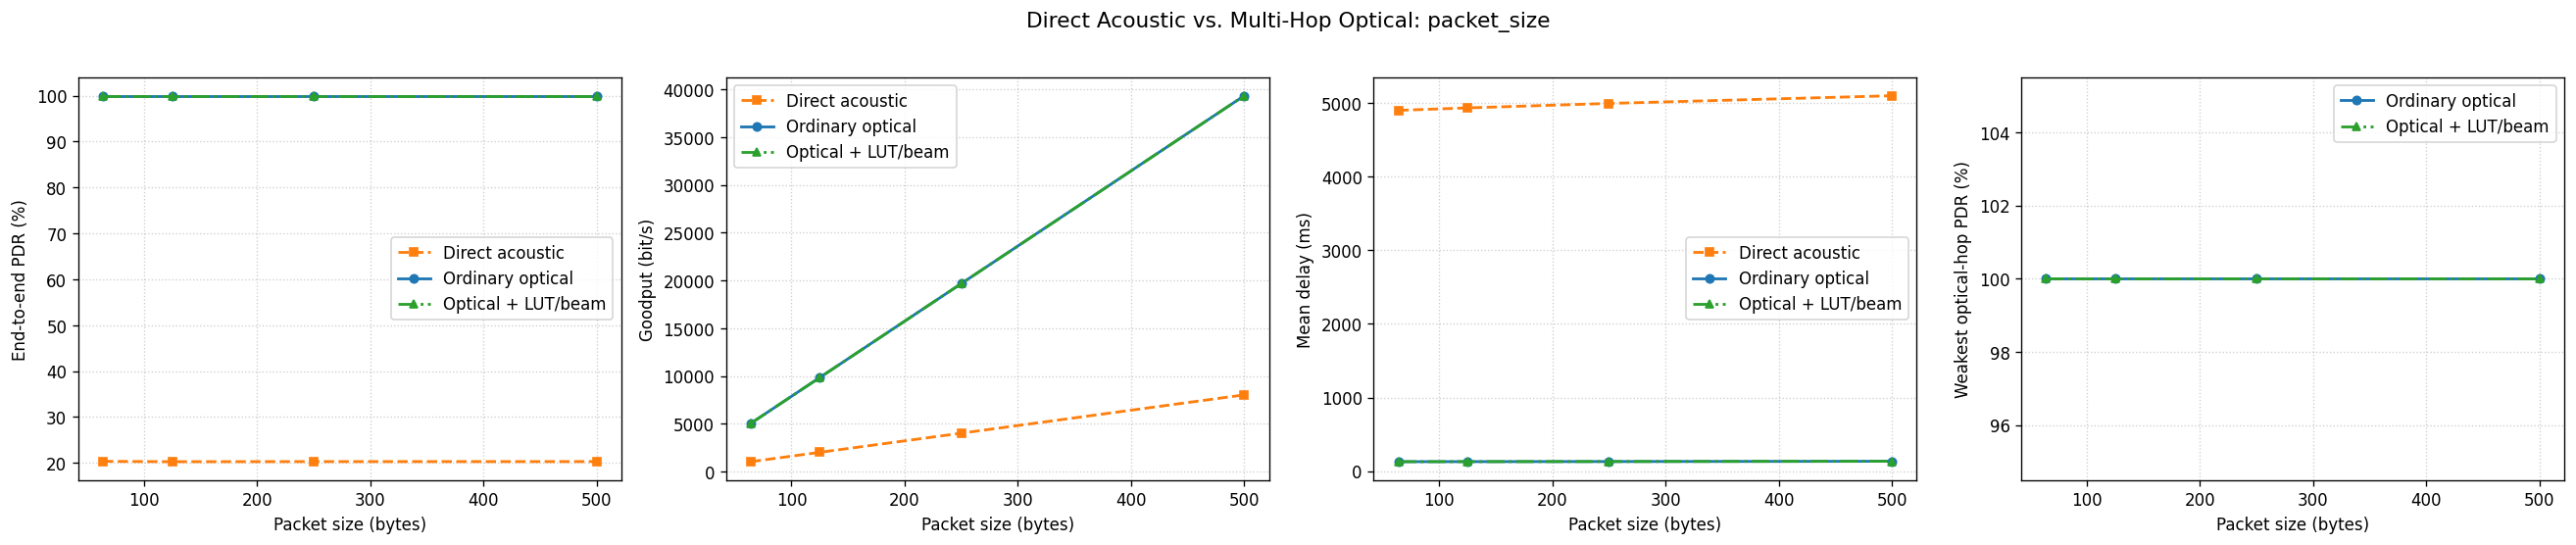

In [16]:
colors = {
    "acoustic": "tab:orange",
    "optical": "tab:blue",
    "beam_optical": "tab:green",
}
labels = {
    "acoustic": "Direct acoustic",
    "optical": "Ordinary optical",
    "beam_optical": "Optical + LUT/beam",
}
styles = {
    "acoustic": ("s", "--"),
    "optical": ("o", "-"),
    "beam_optical": ("^", "-."),
}
definitions = {
    "total_distance": "Total source-destination distance (m)",
    "relay_count": "Optical relay couples",
    "offered_traffic": "CBR mean period (s)",
    "packet_size": "Packet size (bytes)",
}


for sweep, xlabel in definitions.items():
    selected = df_summary[df_summary["sweep"] == sweep].copy()
    if selected.empty:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), dpi=120)
    for technology in ("acoustic", "optical", "beam_optical"):
        pts = selected[selected["technology"] == technology].sort_values("sweep_value")
        if pts.empty:
            continue
        x = pts["sweep_value"].astype(float)
        marker, linestyle = styles[technology]
        style = {
            "marker": marker,
            "linestyle": linestyle,
            "color": colors[technology],
            "label": labels[technology],
            "linewidth": 1.7,
            "markersize": 5,
        }
        axes[0].plot(x, 100 * pts["pdr_mean"], **style)
        axes[1].plot(x, pts["goodput_bps_mean"], **style)
        axes[2].plot(x, 1000 * pts["delay_mean_s_mean"], **style)
        if technology != "acoustic":
            axes[3].plot(
                x, 100 * pts["weakest_hop_pdr_mean"], **style
            )

    axes[0].set_ylabel("End-to-end PDR (%)")
    axes[1].set_ylabel("Goodput (bit/s)")
    axes[2].set_ylabel("Mean delay (ms)")
    axes[3].set_ylabel("Weakest optical-hop PDR (%)")
    for axis in axes:
        axis.set_xlabel(xlabel)
        axis.grid(True, linestyle=":", alpha=0.6)
        axis.legend(frameon=True)
    fig.suptitle(f"Direct Acoustic vs. Multi-Hop Optical: {sweep}", fontsize=13, y=1.02)
    fig.tight_layout()
    save_path = OUTPUT_DIR / f"comparison_{sweep}.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print(f"Saved plot: {save_path}")
    plt.show()